<a href="https://colab.research.google.com/github/Bunkhuoch-Ann/Side_Quests_simple/blob/main/Rain_drop_exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Initialization**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

video_path = "/content/20260713_104127.mp4"

cap = cv2.VideoCapture(video_path)

# Video information
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"FPS       = {fps}")
print(f"Frames    = {n_frames}")
print(f"Resolution = {width} x {height}")

# Read all frames
frames = []

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # Convert RGB/BGR image to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    frames.append(gray)

cap.release()

# Convert to numpy array
cube = np.array(frames)

print("Data cube shape:", cube.shape)

FPS       = 59.4401246134811
Frames    = 940
Resolution = 1080 x 1920
Data cube shape: (940, 1920, 1080)


In [ ]:
# ============================================================
# USER PARAMETERS
# ============================================================

x_center = 645      # center x position of the vertical strip [pixel]

delta_x = 35        # width of the strip [pixel]
x_min = int(x_center - delta_x / 2)
x_max = int(x_center + delta_x / 2)

print("x range:", x_min, "to", x_max)

x range: 627 to 662


**Cropping only the region of the rain drop**

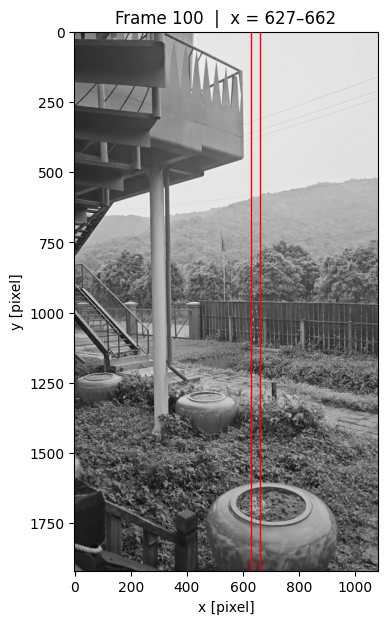

In [ ]:
# ============================================================
# FRAME TO DISPLAY
# ============================================================

frame_number = 100

frame = cube[frame_number]

plt.figure(figsize=(10, 7))

plt.imshow(frame, cmap="gray", origin="upper")

# Rectangle boundaries
plt.axvline(x_min, color="red", linewidth=1)
plt.axvline(x_max, color="red", linewidth=1)

plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
plt.title(f"Frame {frame_number}  |  x = {x_min}–{x_max}")

plt.show()

In [ ]:
# Select the x region
strip = cube[:, :, x_min:x_max]

print("Strip shape:", strip.shape)

# Average over x
Iy_t = np.mean(strip, axis=2)

print("Iy_t shape:", Iy_t.shape)

Strip shape: (940, 1920, 35)
Iy_t shape: (940, 1920)


**Observation in time dimension**

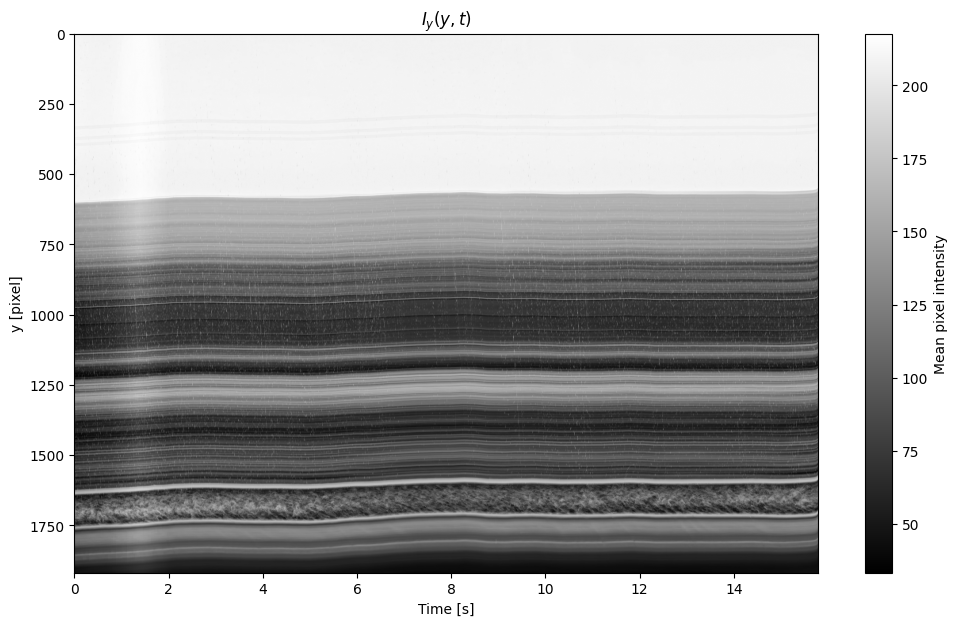

In [ ]:
# Convert frame number to time
time = np.arange(n_frames) / fps

plt.figure(figsize=(12, 7))

plt.imshow(
    Iy_t.T,
    aspect="auto",
    origin="upper",
    extent=[time[0], time[-1], height - 1, 0],
    cmap="gray"
)

plt.xlabel("Time [s]")
plt.ylabel("y [pixel]")
plt.title(r"$I_y(y,t)$")

plt.colorbar(label="Mean pixel intensity")

plt.show()

**Performing Camera motion correction**

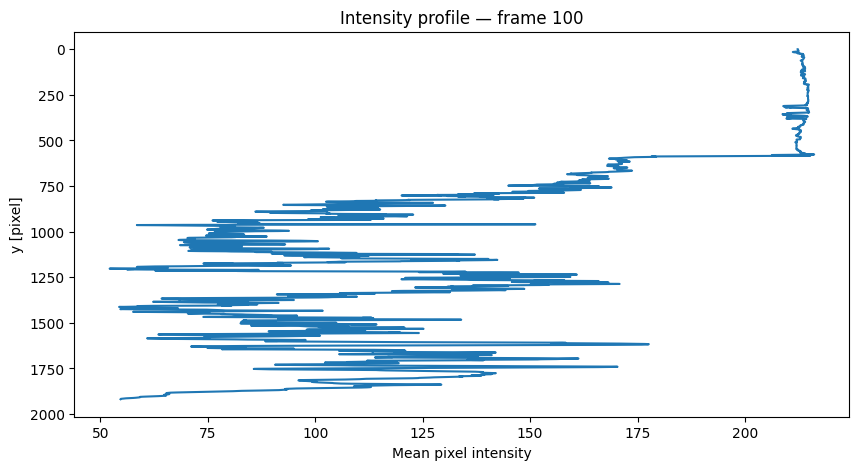

In [ ]:
frame_number = 100

profile = Iy_t[frame_number]

plt.figure(figsize=(10, 5))

plt.plot(profile, np.arange(height))

plt.xlabel("Mean pixel intensity")
plt.ylabel("y [pixel]")
plt.title(f"Intensity profile — frame {frame_number}")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

# ============================================================
# USER PARAMETERS
# ============================================================

y_search = 350       # center of the search region [pixel]
delta_y = 300        # total width of search region [pixel]

# Gaussian smoothing width
smooth_sigma = 2    # <-- tune this

# Peak detection parameters
prominence = 3      # <-- tune this
width = 3          # <-- approximate minimum feature width

y_min = int(y_search - delta_y / 2)
y_max = int(y_search + delta_y / 2)

print(f"Searching y = {y_min} to {y_max}")

Searching y = 200 to 500


In [ ]:
frame_number = 100

profile = Iy_t[frame_number]

# Select y region
y_region = np.arange(y_min, y_max)
I_region = profile[y_min:y_max]

# Smooth
I_smooth = gaussian_filter1d(
    I_region.astype(float),
    sigma=smooth_sigma
)

In [ ]:
peaks, properties = find_peaks(
    -I_smooth,
    prominence=prominence,
    width=width
)

# Convert local indices back to global y coordinates
peak_y = y_region[peaks]

print("Detected feature centers:", peak_y)

Detected feature centers: [314 358 376]


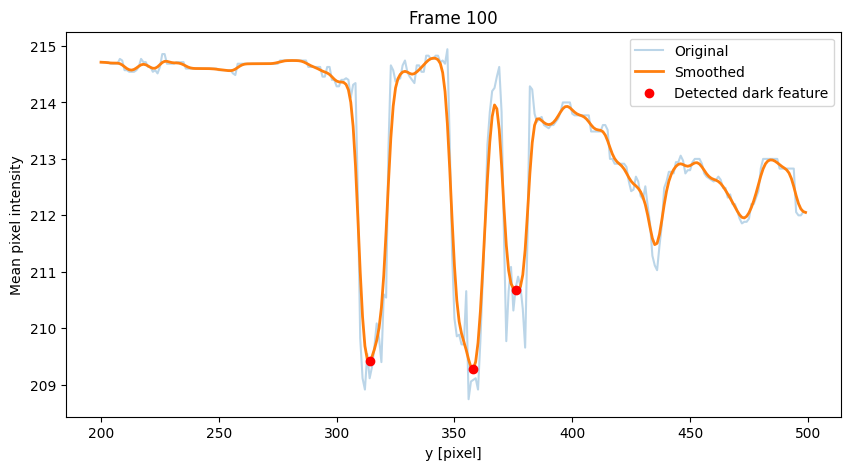

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_region,
    I_region,
    alpha=0.3,
    label="Original"
)

plt.plot(
    y_region,
    I_smooth,
    linewidth=2,
    label="Smoothed"
)

plt.scatter(
    peak_y,
    I_smooth[peaks],
    color="red",
    zorder=5,
    label="Detected dark feature"
)

plt.xlabel("y [pixel]")
plt.ylabel("Mean pixel intensity")
plt.title(f"Frame {frame_number}")

plt.legend()
plt.show()

In [ ]:
# ============================================================
# DETECT THE 2 FEATURES IN EVERY FRAME
# ============================================================

n_frames = Iy_t.shape[0]

# Store the two detected peak positions
peak_positions = np.full((n_frames, 3), np.nan)

for t in range(n_frames):

    profile = Iy_t[t]

    # Same search region as before
    I_region = profile[y_min:y_max]

    # Smooth
    I_smooth = gaussian_filter1d(
        I_region.astype(float),
        sigma=smooth_sigma
    )

    # Find dark features
    peaks, properties = find_peaks(
        -I_smooth,
        prominence=prominence,
        width=width
    )

    peak_y = y_region[peaks]

    # We expect 2 features
    if len(peak_y) >= 3:

        # Take the two strongest peaks
        strongest = np.argsort(properties["prominences"])[-3:]

        detected = np.sort(peak_y[strongest])

        peak_positions[t] = detected

print("Finished detecting peaks.")

Finished detecting peaks.


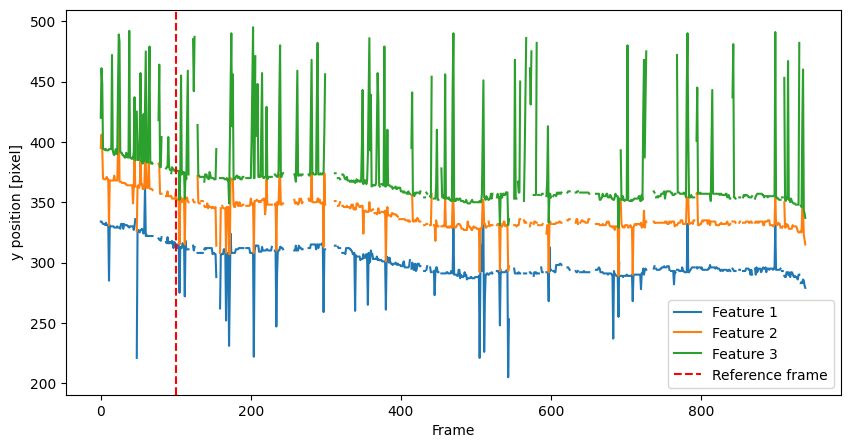

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    peak_positions[:, 0],
    label="Feature 1"
)

plt.plot(
    peak_positions[:, 1],
    label="Feature 2"
)

plt.plot(
    peak_positions[:, 2],
    label="Feature 3"
)

plt.axvline(
    frame_number,
    color="red",
    linestyle="--",
    label="Reference frame"
)

plt.xlabel("Frame")
plt.ylabel("y position [pixel]")
plt.legend()
plt.show()

In [ ]:
reference_frame = 100

reference_positions = peak_positions[reference_frame]

print("Reference positions:", reference_positions)

peak_shifts = peak_positions - reference_positions
camera_shift_raw = np.nanmin(peak_shifts, axis=1)

Reference positions: [314. 358. 376.]


/tmp/ipykernel_4584/1396922414.py:8: RuntimeWarning: All-NaN slice encountered
  camera_shift_raw = np.nanmin(peak_shifts, axis=1)


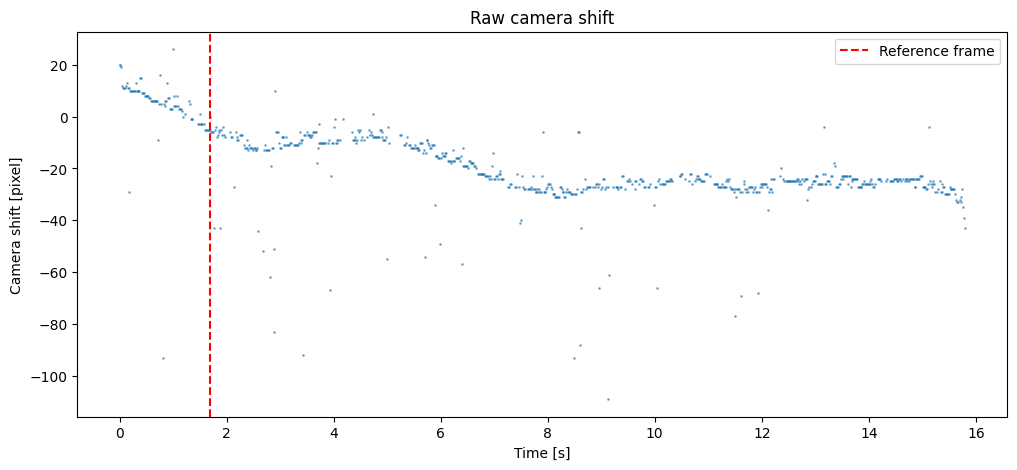

In [ ]:
time = np.arange(n_frames) / fps

plt.figure(figsize=(12, 5))

plt.plot(
    time,
    camera_shift_raw,
    ".",
    markersize=2,
    alpha=0.5
)

plt.axvline(
    time[reference_frame],
    color="red",
    linestyle="--",
    label="Reference frame"
)

plt.xlabel("Time [s]")
plt.ylabel("Camera shift [pixel]")
plt.title("Raw camera shift")
plt.legend()
plt.show()

In [ ]:
from astropy.stats import sigma_clip

clipped = sigma_clip(
    camera_shift_raw,
    sigma=3.7,
    maxiters=5
)

good = ~clipped.mask

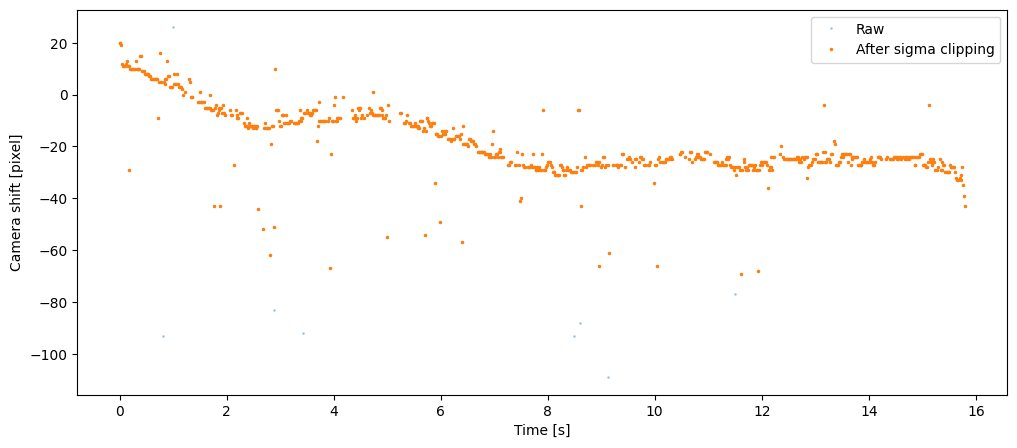

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    time,
    camera_shift_raw,
    ".",
    markersize=2,
    alpha=0.3,
    label="Raw"
)

plt.plot(
    time[good],
    camera_shift_raw[good],
    ".",
    markersize=3,
    label="After sigma clipping"
)

plt.xlabel("Time [s]")
plt.ylabel("Camera shift [pixel]")
plt.legend()

plt.show()

In [ ]:
poly_degree = 11

coefficients = np.polyfit(
    time[good],
    camera_shift_raw[good],
    poly_degree
)

camera_shift_smooth = np.polyval(
    coefficients,
    time
)

# from scipy.interpolate import UnivariateSpline

# spline = UnivariateSpline(
#     time[good],
#     camera_shift_raw[good],
#     s=10000
# )

# camera_shift_smooth = spline(time)

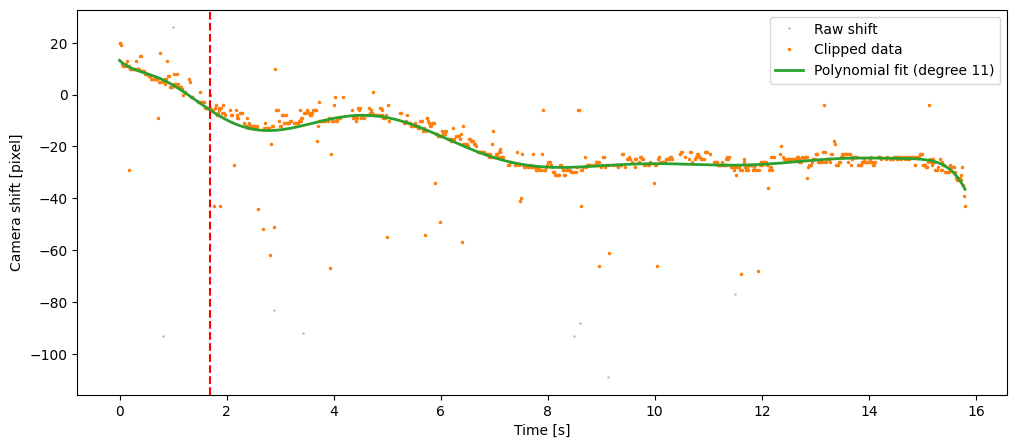

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    time,
    camera_shift_raw,
    ".",
    markersize=2,
    alpha=0.3,
    label="Raw shift"
)

plt.plot(
    time[good],
    camera_shift_raw[good],
    ".",
    markersize=3,
    label="Clipped data"
)

plt.plot(
    time,
    camera_shift_smooth,
    linewidth=2,
    label=f"Polynomial fit (degree {poly_degree})"
)

plt.axvline(
    time[reference_frame],
    color="red",
    linestyle="--"
)

plt.xlabel("Time [s]")
plt.ylabel("Camera shift [pixel]")
plt.legend()

plt.show()

In [ ]:
from scipy.ndimage import shift

Iy_corrected = np.empty_like(Iy_t, dtype=float)

for t in range(n_frames):

    Iy_corrected[t] = shift(
        Iy_t[t].astype(float),
        -camera_shift_smooth[t],
        mode="nearest"
    )

**Corrected image**

In [ ]:
time = np.arange(n_frames) / fps

plt.figure(figsize=(12, 6))

plt.imshow(
    Iy_corrected.T,
    aspect="auto",
    origin="upper",
    extent=[
        time[0],
        time[-1],
        Iy_corrected.shape[1] - 1,
        0
    ],
    cmap="gray_r"
)

plt.xlabel("Time [s]")
plt.ylabel("y [pixel]")
plt.title("Stability-corrected $I_y(y,t)$")

plt.colorbar(
    label="Mean pixel intensity"
)

plt.show()

Original shape: (940, 1920)
Cropped shape: (940, 800)


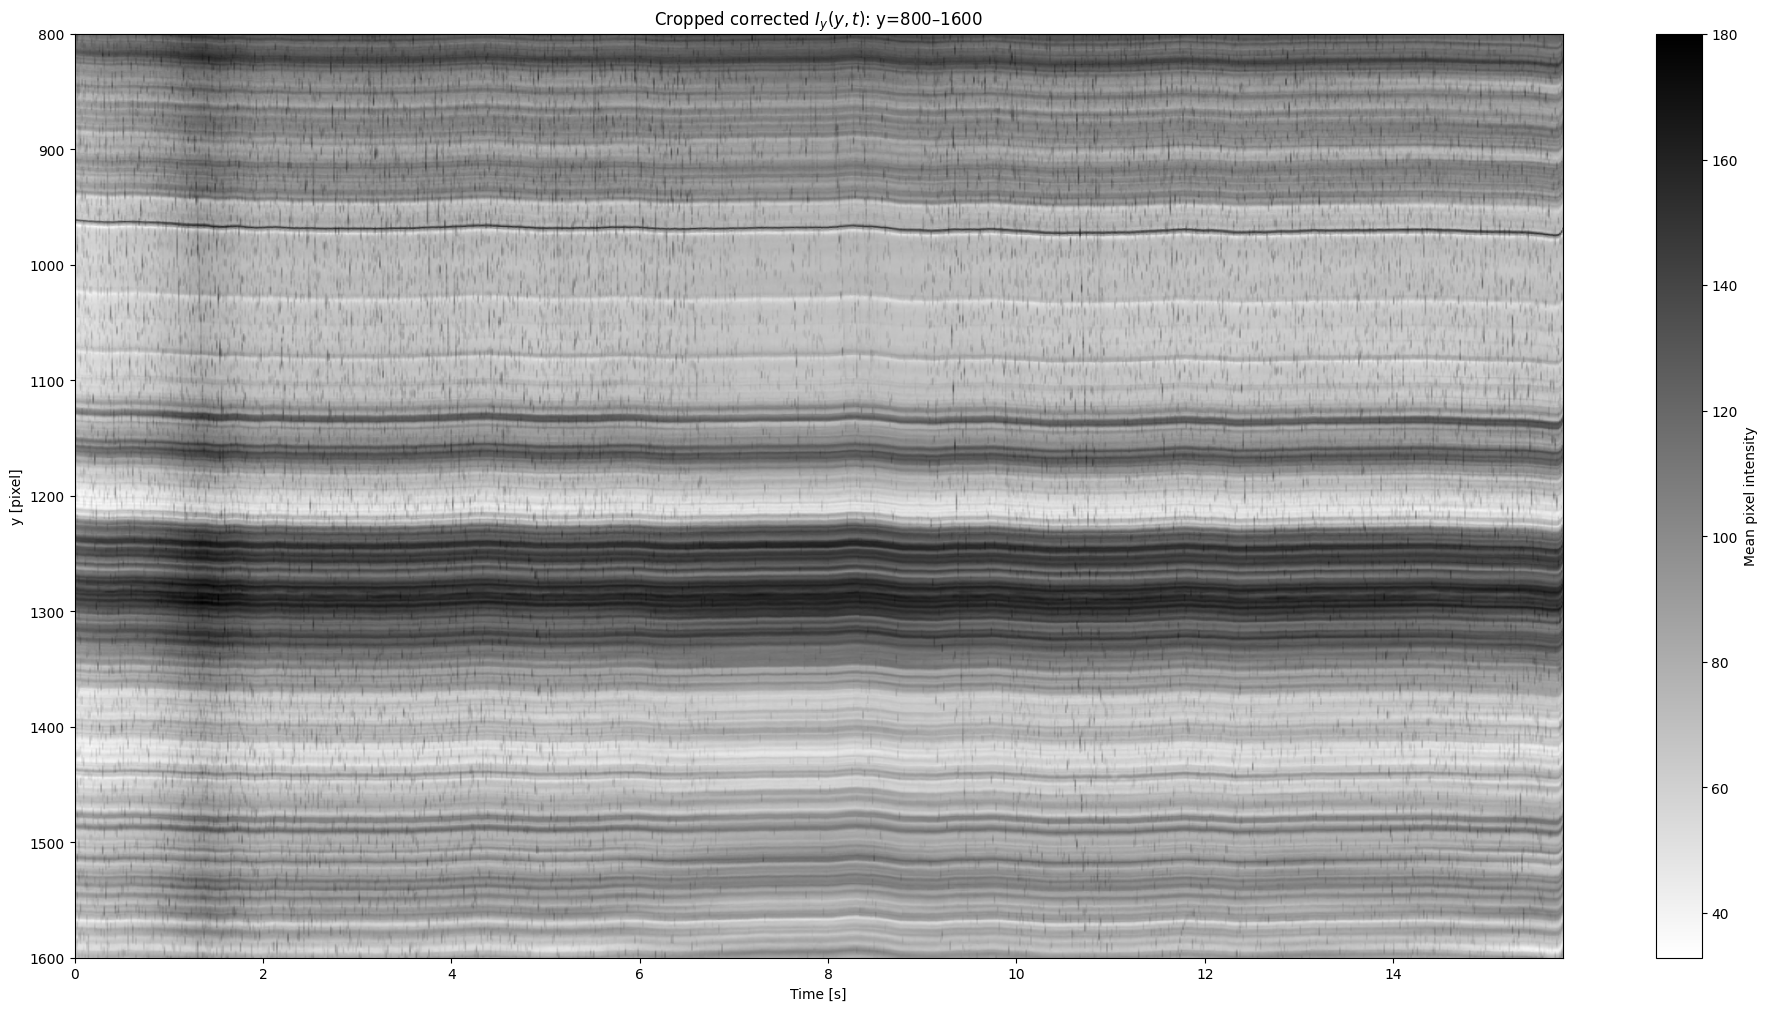

In [ ]:
# ============================================================
# Y RANGE FOR DROPLET ANALYSIS
# ============================================================

y_start = 800       # <-- tune this
y_end   = 1600      # <-- tune this

Iy_crop = Iy_corrected[:, y_start:y_end]

print("Original shape:", Iy_corrected.shape)
print("Cropped shape:", Iy_crop.shape)

time = np.arange(Iy_crop.shape[0]) / fps

plt.figure(figsize=(24, 12))

plt.imshow(
    Iy_crop.T,
    aspect="auto",
    origin="upper",
    extent=[
        time[0],
        time[-1],
        y_end,
        y_start
    ],
    cmap="gray_r"
)

plt.xlabel("Time [s]")
plt.ylabel("y [pixel]")
plt.title(f"Cropped corrected $I_y(y,t)$: y={y_start}–{y_end}")

plt.colorbar(label="Mean pixel intensity")

plt.show()

In [ ]:
# First time to the code use this line and restart the session
#!pip install -q ipympl
# !pip install -q -U plotly anywidget

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Heatmap(
        z=Iy_crop.T,
        x=time,
        y=np.arange(y_start, y_end),
        colorscale="Gray"
    )
)

fig.update_layout(
    width=1200,
    height=700,
    xaxis_title="Time [s]",
    yaxis_title="y [pixel]"
)

fig.show()

**Manually tracing the rain drop trajectory**

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

# Storage
all_points = []
current_points = []
drop_id = 1

# Heatmap must have shape: (len(y), len(time))
y_coord = np.arange(y_start, y_end)
z_img = np.asarray(Iy_crop).T

assert z_img.shape == (len(y_coord), len(time)), (
    f"Expected {(len(y_coord), len(time))}, got {z_img.shape}"
)

fig = go.FigureWidget()

# Intensity image
fig.add_trace(
    go.Heatmap(
        z=z_img,
        x=time,
        y=y_coord,
        colorscale="Gray_r",
        showscale=True,
        colorbar=dict(title="Intensity"),
        hoverinfo="none",
        # hovertemplate=(
        #     "Time: %{x:.3f} s<br>"
        #     "y: %{y:.1f} px"
        #     "<extra></extra>"
        # ),
    )
)

# One marker trace, updated after every click
fig.add_trace(
    go.Scatter(
        x=[],
        y=[],
        mode="markers+lines",
        marker=dict(size=3, color="red"),
        line=dict(color="red", width=1),
        name="Selected points",
        hovertemplate="t=%{x:.3f} s, y=%{y:.1f} px<extra></extra>",
    )
)

fig.update_layout(
    width=1700,
    height=1000,
    title="Click points along a rain drop",
    xaxis_title="Time [s]",
    yaxis_title="y [pixel]",
    clickmode="event",
    # Small y values at the top; large y values at the bottom
    yaxis=dict(autorange="reversed"),
)

# ---- Controls ----
finish_button = widgets.Button(
    description="Finish drop → next",
    button_style="success"
)

undo_button = widgets.Button(
    description="Undo last point",
    button_style="warning"
)

clear_button = widgets.Button(
    description="Discard current drop",
    button_style="danger"
)

status = widgets.HTML()


def update_marker_trace():
    """Redraw markers/line for the drop currently being selected."""
    with fig.batch_update():
        fig.data[1].x = [p[0] for p in current_points]
        fig.data[1].y = [p[1] for p in current_points]

    status.value = (
        f"<b>Currently selecting Drop {drop_id}</b> "
        f"({len(current_points)} points)"
    )


def handle_click(trace, points, selector):
    if len(points.xs) == 0:
        return

    t_click = float(points.xs[0])
    y_click = float(points.ys[0])

    current_points.append((t_click, y_click))
    update_marker_trace()

    print(f"Drop {drop_id}: t = {t_click:.3f} s, y = {y_click:.2f} px")


def finish_drop(button):
    """Save current drop, keep it displayed, and begin the next drop."""
    global current_points, drop_id

    if len(current_points) == 0:
        print(f"Drop {drop_id} has no points yet.")
        return

    # Save the coordinates
    saved_points = np.array(current_points, dtype=float)
    all_points.append(saved_points)

    # Give each completed drop a distinct color
    hue = (drop_id * 47) % 360
    drop_color = f"hsl({hue}, 85%, 50%)"

    # Add a PERMANENT trajectory trace to the figure
    fig.add_trace(
        go.Scatter(
            x=saved_points[:, 0],
            y=saved_points[:, 1],
            mode="markers+lines",
            marker=dict(size=3, color=drop_color),
            line=dict(width=1.5, color=drop_color),
            name=f"Drop {drop_id}",
            showlegend=False,     # Prevent a huge legend for many drops
            hoverinfo="none",
            # hovertemplate=(
            #     f"Drop {drop_id}<br>"
            #     "t = %{x:.3f} s<br>"
            #     "y = %{y:.1f} px"
            #     "<extra></extra>"
            # ),

        )
    )

    print(f"Saved Drop {drop_id} with {len(current_points)} points.")

    # Clear only the red current-selection trace
    current_points = []
    drop_id += 1
    update_marker_trace()


def undo_last_point(button):
    """Remove only the most recently clicked point."""
    if len(current_points) == 0:
        print("There is no point to undo.")
        return

    removed = current_points.pop()
    print(f"Removed: t = {removed[0]:.3f} s, y = {removed[1]:.2f} px")
    update_marker_trace()


def discard_current_drop(button):
    """Delete every currently selected point without saving the drop."""
    global current_points

    current_points = []
    print(f"Discarded unfinished Drop {drop_id}.")
    update_marker_trace()


# Connect plot and button events
fig.data[0].on_click(handle_click)
finish_button.on_click(finish_drop)
undo_button.on_click(undo_last_point)
clear_button.on_click(discard_current_drop)

update_marker_trace()

display(widgets.HBox([finish_button, undo_button, clear_button]))
display(status)
display(fig)

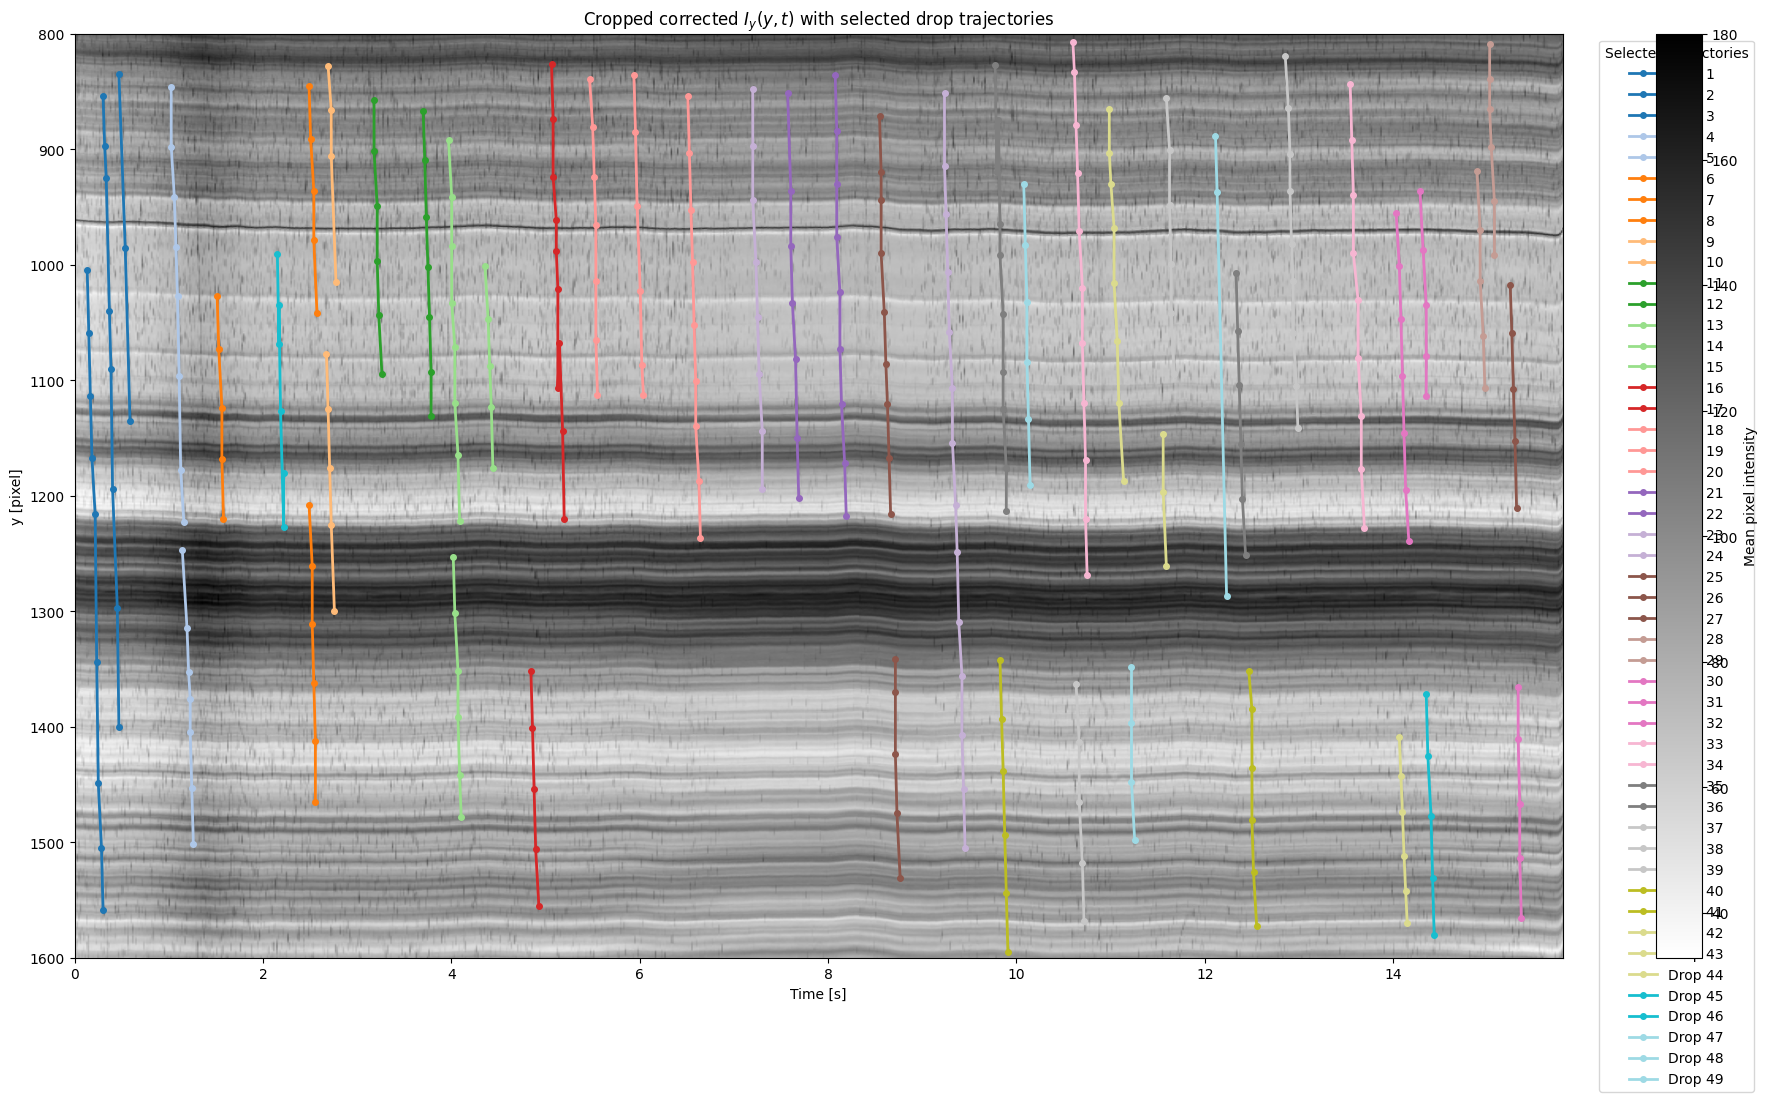

In [ ]:
plt.figure(figsize=(24, 12))

plt.imshow(
    Iy_crop.T,
    aspect="auto",
    origin="upper",
    extent=[time[0], time[-1], y_end, y_start],
    cmap="gray_r",
)

# Overlay saved trajectories
colors = plt.cm.tab20(np.linspace(0, 1, max(len(all_points), 1)))

for i, points in enumerate(all_points):
    points = np.asarray(points)

    if points.size == 0:
        continue

    # points[:, 0] = time, points[:, 1] = y pixel
    order = np.argsort(points[:, 0])
    t_drop = points[order, 0]
    y_drop = points[order, 1]

    plt.plot(
        t_drop, y_drop,
        "-o",
        color=colors[i],
        linewidth=2,
        markersize=4,
        label=f"Drop {i + 1}",
    )

plt.xlabel("Time [s]")
plt.ylabel("y [pixel]")
plt.title(f"Cropped corrected $I_y(y,t)$ with selected drop trajectories")

plt.colorbar(label="Mean pixel intensity")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    title="Selected trajectories",
)

plt.show()

In [ ]:
import pandas as pd
import numpy as np

rows = []

for i, points in enumerate(all_points, start=1):
    points = np.asarray(points, dtype=float)

    for t, y in points:
        rows.append({
            "drop_id": i,
            "y_pixel": y,
            "time_s": t,
        })

df_points = pd.DataFrame(rows)

df_points.to_csv("raindrop_selected_points.csv", index=False)

df_points.head()

,drop_id,y_pixel,time_s
0,1,1005.0,0.134589
1,1,1059.0,0.151413
2,1,1114.0,0.168237
3,1,1167.0,0.185060
4,1,1216.0,0.218707


**Perform the model fitting according to the free fall with initial velocity condition**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# Fit y = A t^2 + B t + C for every completed drop
# ---------------------------------------------------------
fit_results = []

for drop_id, points in enumerate(all_points, start=1):
    points = np.asarray(points, dtype=float)

    # points[:, 0] = time, points[:, 1] = y position
    valid = np.isfinite(points[:, 0]) & np.isfinite(points[:, 1])
    t = points[valid, 0]
    y = points[valid, 1]

    # A quadratic needs at least 3 points
    if len(t) < 3:
        print(f"Drop {drop_id}: skipped (only {len(t)} valid points)")
        continue

    # Sort points in time order
    order = np.argsort(t)
    t = t[order]
    y = y[order]

    # Coordinates relative to the first selected point of this drop
    delta_t = t - t[0]
    delta_y = y - y[0]

    # Fit: delta_y = A * delta_t^2 + B * delta_t + C
    A, B, C = np.polyfit(delta_t, delta_y, deg=2)

    fit_results.append({
        "drop_id": drop_id,
        "A": A,
        "B": B,
        "C": C,
        "n_points": len(t),

        # Optional: retain the reference point for later use
        "t0": t[0],
        "y0": y[0],
    })

fit_df = pd.DataFrame(fit_results)

print(fit_df.head())
print(f"\nNumber of fitted drops: {len(fit_df)}")

   drop_id             A            B             C  n_points        t0  \
0        1   1413.762866  3140.794144 -2.349801e+00         9  0.134589   
1        2   2242.197996  2835.217396 -8.344714e+00         8  0.302826   
2        3   6014.730514  1839.105760 -1.640928e-14         3  0.471062   
3        4   2419.278059  2457.426646  2.036861e+01         8  1.026243   
4        5  12733.983659   681.332428  2.083333e-01         7  1.144008   

       y0  
0  1005.0  
1   854.0  
2   835.0  
3   846.0  
4  1247.0  

Number of fitted drops: 49


/tmp/ipykernel_4584/968610656.py:33: RankWarning: Polyfit may be poorly conditioned
  A, B, C = np.polyfit(delta_t, delta_y, deg=2)
/tmp/ipykernel_4584/968610656.py:33: RankWarning: Polyfit may be poorly conditioned
  A, B, C = np.polyfit(delta_t, delta_y, deg=2)


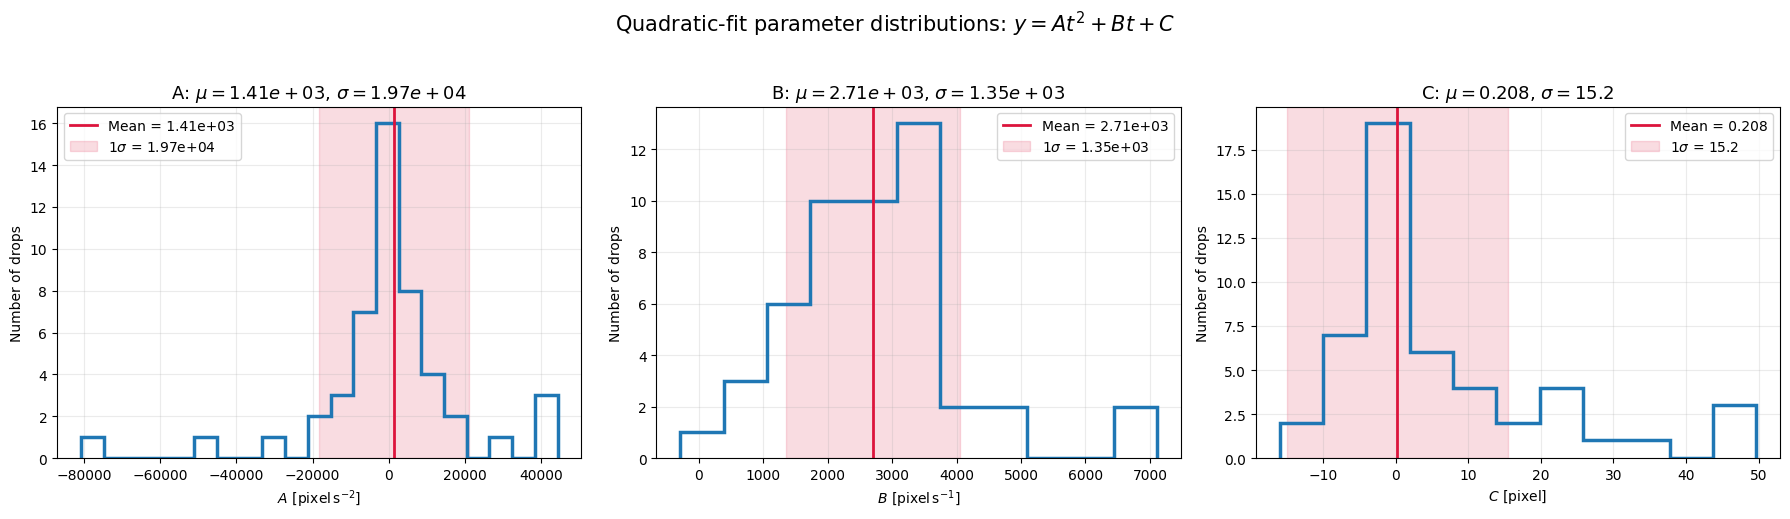

In [ ]:
# ---------------------------------------------------------
# Distributions of A, B, and C
# ---------------------------------------------------------
parameters = [
    ("A", r"$A\ [{\rm pixel}\,{\rm s}^{-2}]$"),
    ("B", r"$B\ [{\rm pixel}\,{\rm s}^{-1}]$"),
    ("C", r"$C\ [{\rm pixel}]$"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (parameter, xlabel) in zip(axes, parameters):
    values = fit_df[parameter].to_numpy()
    values = values[np.isfinite(values)]

    mean = np.median(values)
    std = np.std(values, ddof=1)   # sample standard deviation

    ax.hist(
        values,
        bins="auto",
        histtype="step",
        linewidth=2.5,
        color="tab:blue",
    )

    ax.axvline(mean, color="crimson", linewidth=2, label=fr"Mean = {mean:.3g}")
    ax.axvspan(
        mean - std, mean + std,
        color="crimson",
        alpha=0.15,
        label=fr"$1\sigma$ = {std:.3g}",
    )

    ax.set_title(
        fr"{parameter}: $\mu={mean:.3g}$, $\sigma={std:.3g}$",
        fontsize=13,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of drops")
    ax.legend()
    ax.grid(alpha=0.25)

fig.suptitle(r"Quadratic-fit parameter distributions: $y = At^2 + Bt + C$",
             fontsize=15, y=1.03)

plt.tight_layout()
plt.show()

**The values are poorly constrainted due low time resolution (60fps)**

In [ ]:
# ---------------------------------------------------------
# v0 = 9.81 * B / (2 * A)
# Uncertainty propagated from the A and B distributions
# ---------------------------------------------------------
A_med = np.nanmedian(fit_df["A"])
B_med = np.nanmedian(fit_df["B"])

A_std = np.nanstd(fit_df["A"], ddof=1)
B_std = np.nanstd(fit_df["B"], ddof=1)

g = 9.81  # m s^-2

v0 = g * B_med / (2 * A_med)

# Partial derivatives of v0 = g*B/(2*A)
dv_dA = -g * B_med / (2 * A_med**2)
dv_dB =  g / (2 * A_med)

v0_std = np.sqrt(
    (dv_dA * A_std)**2 +
    (dv_dB * B_std)**2
)

print(f"A = {A_med:.4g} ± {A_std:.4g} pixel s^-2")
print(f"B = {B_med:.4g} ± {B_std:.4g} pixel s^-1")
print(f"\nv₀ = {v0:.4g} ± {v0_std:.4g} m s^-1")

A = 1414 ± 1.973e+04 pixel s^-2
B = 2706 ± 1350 pixel s^-1

v₀ = 9.389 ± 131.1 m s^-1


In [ ]:
# ---------------------------------------------------------
# Free-fall height: h0 = v0^2 / (2g)
# ---------------------------------------------------------
h0 = v0**2 / (2 * g)

# Uncertainty propagation from v0
h0_std = np.abs(v0 / g) * v0_std

print(f"h₀ = {h0:.4g} ± {h0_std:.4g} m")

h₀ = 4.494 ± 24.69 m


In [ ]:
# import subprocess

# result = subprocess.run(
#     [
#         "ffprobe",
#         "-v", "quiet",
#         "-print_format", "json",
#         "-show_format",
#         "-show_streams",
#         video_path,
#     ],
#     capture_output=True,
#     text=True,
# )

# print(result.stdout)